## Exploratory Data Analysis 

This notebook provides dataset structure and quality inspection for each dataset, analyzing data types, missing values and duplicates rows.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import warnings

# Configure pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. Inspection Function

The `inspect_dataset(df, dataset_name)` function inspects data types, missing values, unique values, sample entries, and duplicate rows for a given dataset.

In [9]:
def inspect_dataset(df, dataset_name="Dataset"):
    """
    Inspection of data types, missing values, unique counts, sample entries, and duplicate rows.
    """
    print(f"Inspection Report: {dataset_name}")
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")
    
    # Column-level summary
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2) if len(df) > 0 else 0,
        'Unique Values': df.nunique(),
        'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
    })
    
    # Duplicate rows count
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df) * 100) if len(df) > 0 else 0
    print(f"\nDuplicate Rows: {dup_count:,}")

    
    return summary_df

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def univariate_analysis(df, categorical_cols, numerical_cols=None):
  """Performs univariate analysis with summary stats,

  value counts, and distribution plots.
  """
  # 1. Numerical & ID Summary Statistics
  if numerical_cols:
    print("=== Numerical Feature Summary ===")
    display(df[numerical_cols].describe())
    print("\n" + "=" * 50 + "\n")

  # 2. Categorical Distribution & Plots
  print("=== Categorical Feature Distributions ===")
  for col in categorical_cols:
    print(f"\nTop 10 Value Counts for: **{col}**")
    top_counts = df[col].value_counts().head(10)
    display(top_counts)

    # Plotting the distribution of top categories
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=df, y=col, order=df[col].value_counts().index[:10], palette="Blues_r"
    )
    plt.title(f"Top 10 Distribution - {col}", fontsize=12, fontweight="bold")
    plt.xlabel("Count", fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.show()
    print("-" * 50)


# Run the analysis on your dataset
categorical_cols = ["Bank Name", "Entity Name"]
numerical_cols = ["Bank ID"]



### 2. Importing Datasets

Load each dataset explicitly into its own variable.

In [3]:
# Load Accounts CSVs
hi_small_accounts = pd.read_csv("data/HI-Small_accounts.csv")
hi_medium_accounts = pd.read_csv("data/HI-Medium_accounts.csv")
li_small_accounts = pd.read_csv("data/LI-Small_accounts.csv")
li_medium_accounts = pd.read_csv("data/LI-Medium_accounts.csv")

# Load Transactions CSVs (sample of 100,000 rows for large transaction files)
hi_small_trans = pd.read_csv("data/HI-Small_Trans.csv", nrows=100000)
li_small_trans = pd.read_csv("data/LI-Small_Trans.csv", nrows=100000)

# Load Patterns 
hi_medium_patterns = pd.read_csv('data/HI-Medium_Patterns.txt', sep = ',')
hi_small_patterns = pd.read_csv('data/HI-Small_Patterns.txt', sep = ',')
li_medium_patterns = pd.read_csv('data/LI-Medium_Patterns.txt', sep = ',')
li_small_patterns = pd.read_csv('data/LI-Small_Patterns.txt', sep = ',')

### 3. Dataset Inspections

### 3.1 Input Inspections

#### 3.1.1. HI-Small Accounts Inspection

Inspection Report: HI-Small Accounts
Dataset Shape: 518,581 rows × 5 columns


Duplicate Rows: 0
=== Numerical Feature Summary ===


,Bank ID
count,518581.000000
mean,103425.510831
std,121479.549761
min,1.000000
25%,11107.000000
50%,32014.000000
75%,217096.000000
max,356303.000000




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
Savings Bank of Fairfield      2642
First Bank of Tampa            2464
Savings Bank of Huron          2379
Savings Bank of Los Angeles    2052
Golden Bancorp                 1967
Name: Bank Name, dtype: int64

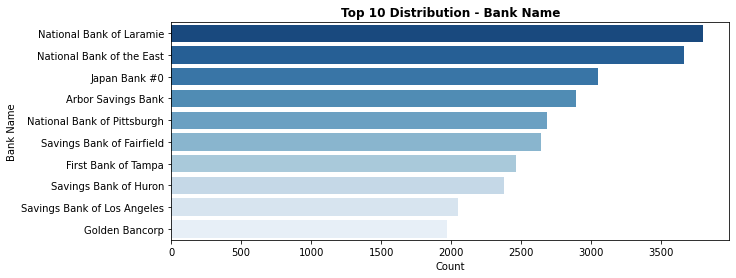

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Corporation #34854            7820
Country #1                    6677
Corporation #35871            4645
Sole Proprietorship #32941    3743
Corporation #33736            3402
Partnership #32618            3309
Partnership #33830            3057
Partnership #37705            2744
Partnership #36544            2705
Partnership #38444            2511
Name: Entity Name, dtype: int64

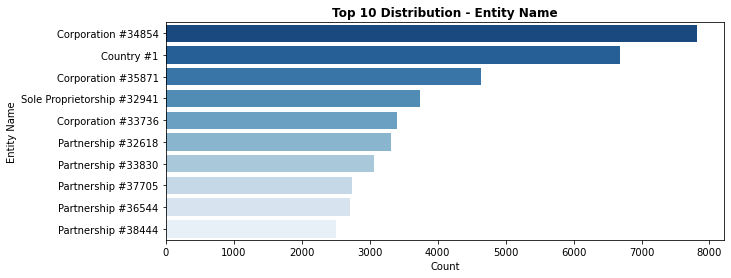

--------------------------------------------------


In [10]:
inspect_dataset(hi_small_accounts, dataset_name="HI-Small Accounts")
univariate_analysis(hi_small_accounts, categorical_cols, numerical_cols)

#### 3.1.2. HI-Small Transactions Inspection

In [ ]:
inspect_dataset(hi_small_trans, dataset_name="HI-Small Transactions")

# Adjust these column names to match whatever your transaction dataset uses
trans_categorical = ["Payment Format", "Payment Currency", "Receiving Currency"]
trans_numerical = [
    "Amount Received",
    "Amount Paid",
]  # Or whatever your amount columns are named

# Run on your transaction dataset
comprehensive_univariate_analysis(
    hi_small_transactions,  # Replace with your actual transaction dataframe variable name
    categorical_cols=trans_categorical,
    numerical_cols=trans_numerical,

Inspection Report: HI-Small Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,30,2022/09/01 00:20
From Bank,int64,0,0.0,4504,10
Account,object,0,0.0,74761,8000EBD30
To Bank,int64,0,0.0,3808,10
Account.1,object,0,0.0,73022,8000EBD30
Amount Received,float64,0,0.0,69408,3697.34
Receiving Currency,object,0,0.0,12,US Dollar
Amount Paid,float64,0,0.0,69655,3697.34
Payment Currency,object,0,0.0,12,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


#### 3.1.3. HI-Medium Accounts Inspection

Inspection Report: HI-Medium Accounts
Dataset Shape: 2,087,786 rows × 5 columns


Duplicate Rows: 0
=== Numerical Feature Summary ===


,Bank ID
count,2.087786e+06
mean,6.321024e+05
std,9.703746e+05
min,0.000000e+00
25%,3.962400e+04
50%,2.037290e+05
75%,3.812120e+05
max,3.225455e+06




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Savings Bank of Indianapolis    5635
Savings Bank of Seattle         5575
First Bank of Plattsburg        4983
First Bank of Miami             4887
Bank of Miami                   4722
National Bank of Plattsburg     4610
National Bank of New Orleans    4557
Bank of Huron                   4542
Savings Bank of Newbury         4416
National Bank of Los Angeles    4264
Name: Bank Name, dtype: int64

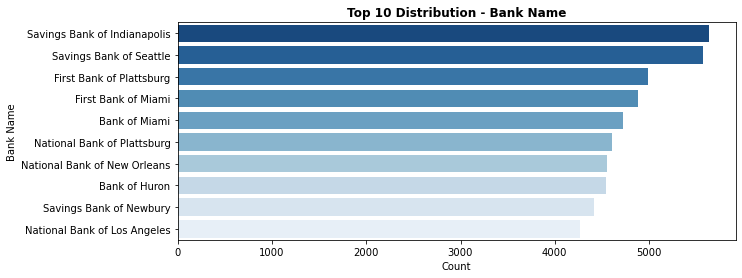

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Corporation #140481            8638
Partnership #139664            5639
Country #1                     4738
Partnership #130756            4714
Sole Proprietorship #145836    4369
Corporation #132573            4237
Sole Proprietorship #144757    4078
Partnership #133653            4058
Corporation #139355            3666
Corporation #140482            3290
Name: Entity Name, dtype: int64

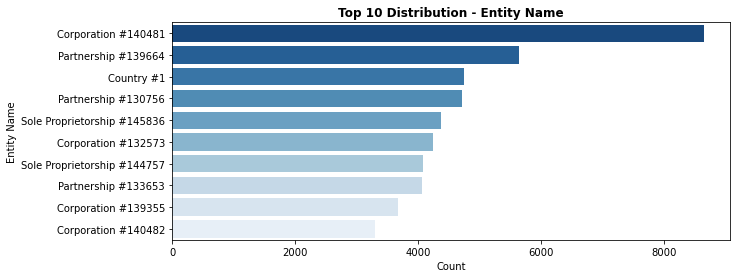

--------------------------------------------------


In [13]:
inspect_dataset(hi_medium_accounts, dataset_name="HI-Medium Accounts")
univariate_analysis(hi_medium_accounts, categorical_cols, numerical_cols)  

#### 3.1.4. LI-Small Accounts Inspection

In [ ]:
inspect_dataset(li_small_accounts, dataset_name="LI-Small Accounts")
univariate_analysis(li_small_accounts, categorical_cols, numerical_cols)  

Inspection Report: LI-Small Accounts
Dataset Shape: 712,688 rows × 5 columns


Duplicate Rows: 0


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,27652,China Bank #2820
Bank ID,int64,0,0.0,41815,314693
Account Number,object,0,0.0,712684,81B86A280
Entity ID,object,0,0.0,224931,800D8CCF0
Entity Name,object,0,0.0,224931,Corporation #41344


#### 3.1.5. LI-Small Transactions Inspection

In [ ]:
inspect_dataset(li_small_trans, dataset_name="LI-Small Transactions")
univariate_analysis(li_small_trans, categorical_cols, numerical_cols)  

Inspection Report: LI-Small Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,30,2022/09/01 00:08
From Bank,int64,0,0.0,4521,11
Account,object,0,0.0,74999,8000ECA90
To Bank,int64,0,0.0,3964,11
Account.1,object,0,0.0,73683,8000ECA90
Amount Received,float64,0,0.0,69794,3195403.0
Receiving Currency,object,0,0.0,12,US Dollar
Amount Paid,float64,0,0.0,70089,3195403.0
Payment Currency,object,0,0.0,12,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


#### 3.1.6. LI-Medium Accounts Inspection

In [ ]:
inspect_dataset(li_medium_accounts, dataset_name="LI-Medium Accounts")
univariate_analysis(li_medium_accounts, categorical_cols, numerical_cols)

Inspection Report: LI-Medium Accounts
Dataset Shape: 2,040,823 rows × 5 columns


Duplicate Rows: 0


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,76636,Bank of New Orleans
Bank ID,int64,0,0.0,119617,9778
Account Number,object,0,0.0,2040789,834A31900
Entity ID,object,0,0.0,654133,2AA23456AF0
Entity Name,object,0,0.0,654133,Corporation #398


#### 3.1.7. HI-Medium Patterns Inspection

In [ ]:
# Versão ultra-simples usando diretamente o DataFrame já carregado
df_summary = hi_medium_patterns.index.to_series().astype(str).str.extract(r'BEGIN LAUNDERING ATTEMPT - ([A-Za-z]+)')[0].value_counts().reset_index()
df_summary.columns = ['Laundering Type', 'Frequency']

display(df_summary)

,Laundering Type,Frequency
0,FAN,700
1,BIPARTITE,369
2,CYCLE,367
3,STACK,335
4,SCATTER,331
5,RANDOM,331
6,GATHER,322


#### 3.1.8. HI-Small Patterns Inspection

In [ ]:
# Versão ultra-simples usando diretamente o DataFrame já carregado
df_summary = hi_small_patterns.index.to_series().astype(str).str.extract(r'BEGIN LAUNDERING ATTEMPT - ([A-Za-z]+)')[0].value_counts().reset_index()
df_summary.columns = ['Laundering Type', 'Frequency']

display(df_summary)

,Laundering Type,Frequency
0,FAN,87
1,CYCLE,54
2,GATHER,51
3,BIPARTITE,49
4,SCATTER,44
5,STACK,43
6,RANDOM,41


#### 3.1.9. LI-Medium Patterns Inspection

In [ ]:
# Versão ultra-simples usando diretamente o DataFrame já carregado
df_summary = li_medium_patterns.index.to_series().astype(str).str.extract(r'BEGIN LAUNDERING ATTEMPT - ([A-Za-z]+)')[0].value_counts().reset_index()
df_summary.columns = ['Laundering Type', 'Frequency']

display(df_summary)

,Laundering Type,Frequency
0,FAN,116
1,BIPARTITE,72
2,STACK,67
3,SCATTER,62
4,RANDOM,49
5,CYCLE,46
6,GATHER,43


#### 3.1.10. LI-Small Patterns Inspection

In [ ]:
# Versão ultra-simples usando diretamente o DataFrame já carregado
df_summary = li_small_patterns.index.to_series().astype(str).str.extract(r'BEGIN LAUNDERING ATTEMPT - ([A-Za-z]+)')[0].value_counts().reset_index()
df_summary.columns = ['Laundering Type', 'Frequency']

display(df_summary)

,Laundering Type,Frequency
0,FAN,30
1,STACK,18
2,BIPARTITE,16
3,RANDOM,15
4,SCATTER,13
5,GATHER,12
6,CYCLE,12


#### 3.1.11. Input Inspections Insights

**Missing Values Assessment:** The transaction dataset contains 0 missing values .No missing data imputation strategies are required for standard transaction fields.

**Duplicate Rows Assessment:** The full transaction dataset contains 9 exact duplicate rows (0.00018%). In the next notebook,to ensure data cleanliness, these duplicate rows will be analyzed to check if they are actually duplicates or just pure coincidence.

**Referential Integrity Assessment:** All account identifiers in the transaction dataset have 0 orphan accounts, which confirms perfect key alignment for entity-level joins. Additionally, as we move further into preprocessing, we will standardize timestamps and currencies to ensure full data consistency across different accounts and transaction types.

### 3.2. Target Inspection

Examining the target variable `Is Laundering` across all transactions to evaluate class imbalance.

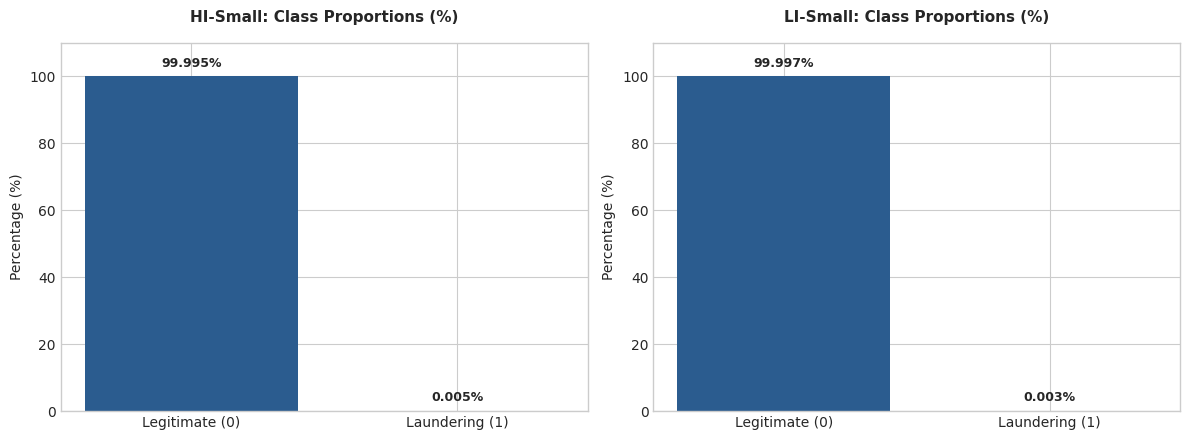

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calcular as percentagens para cada dataset
hi_pct = hi_small_trans['Is Laundering'].value_counts(normalize=True).sort_index() * 100
li_pct = li_small_trans['Is Laundering'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#2b5c8f', '#d9534f']

# --- Gráfico 1: HI-Small ---
bars1 = ax[0].bar(['Legitimate (0)', 'Laundering (1)'], hi_pct.values, color=colors)
ax[0].set_title('HI-Small: Class Proportions (%)', fontsize=11, fontweight='bold', pad=15)
ax[0].set_ylabel('Percentage (%)')
ax[0].set_ylim(0, 110) # Limite linear de 0 a 110% para dar folga à barra de legítimas

for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.3f}%', 
               ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Gráfico 2: LI-Small ---
bars2 = ax[1].bar(['Legitimate (0)', 'Laundering (1)'], li_pct.values, color=colors)
ax[1].set_title('LI-Small: Class Proportions (%)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_ylabel('Percentage (%)')
ax[1].set_ylim(0, 110)

for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.3f}%', 
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


#### Target Inspection Insights

Both datasets show a huge imbalance in the data. Almost all transactions are legitimate, making up about 99.995% to 99.997% of the total. Laundering transactions are extremely rare, representing only 0.003% to 0.005%. Because of this extreme difference, standard machine learning models will struggle, and will need special techniques to handle the imbalanced data.

### 4. Transaction Volume Velocity Over Time

Inspecting transaction timestamps to detect hourly, daily, and velocity patterns.

In [ ]:
print(hi_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max()) 
print(li_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max())

2022-09-01 00:00:00 2022-09-01 00:29:00
2022-09-01 00:00:00 2022-09-01 00:29:00


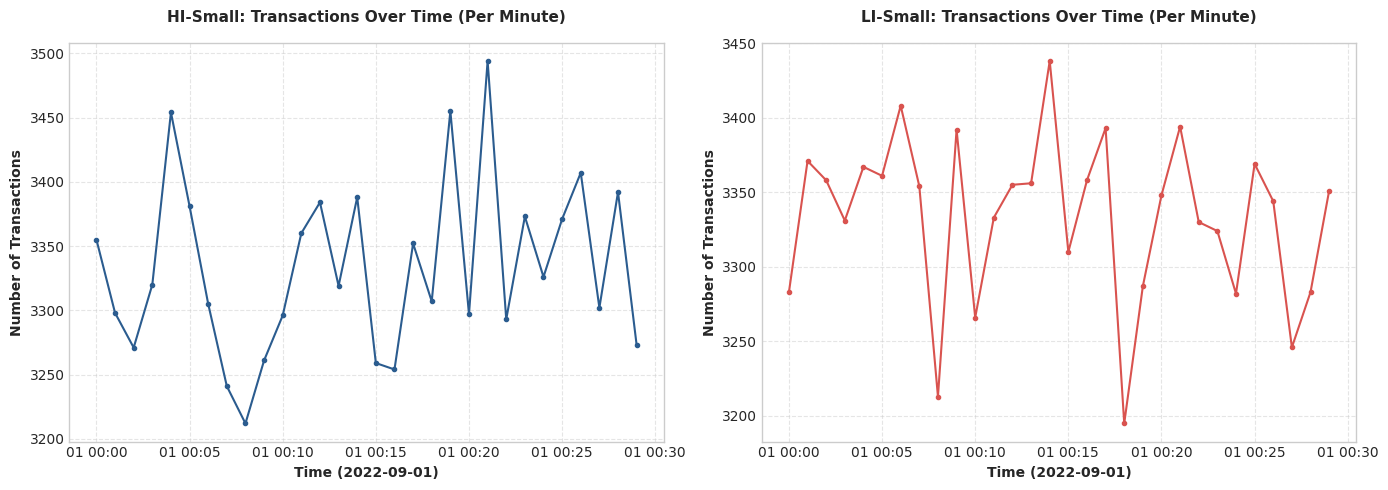

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Garantir que a coluna Timestamp está em formato datetime
hi_small_trans['Timestamp'] = pd.to_datetime(hi_small_trans['Timestamp'])
li_small_trans['Timestamp'] = pd.to_datetime(li_small_trans['Timestamp'])

# Agrupar por minuto ('min') para ver a evolução nos 30 minutos da amostra
hi_minutely = hi_small_trans.set_index('Timestamp').resample('min').size()
li_minutely = li_small_trans.set_index('Timestamp').resample('min').size()

# Criar a figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: HI-Small ---
ax[0].plot(hi_minutely.index, hi_minutely.values, color='#2b5c8f', linewidth=1.5, marker='o', markersize=3)
ax[0].set_title('HI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[0].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[0].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: LI-Small ---
ax[1].plot(li_minutely.index, li_minutely.values, color='#d9534f', linewidth=1.5, marker='o', markersize=3)
ax[1].set_title('LI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[1].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### Transaction Volume Velocity Over Time Insights

The transaction volume remains relatively stable throughout the 30 minutes analyzed, consistently fluctuating within a predictable range of 3,200 to 3,500 transactions per minute. There are no abrupt interruptions or extreme traffic spikes, indicating a continuous and uniform flow within the data sample. Furthermore, both datasets (HI-Small and LI-Small) exhibit very similar pacing behavior.


### 5. Payment Channel Analysis 

Evaluating volume and risk distribution across payment formats (Wire, ACH, Cheque, Credit Card, Reinvestment, etc.).

,Total_Transactions,Laundering_Count,Laundering_Rate_Pct
Payment Format,,,
ACH,600797,4483,0.7462
Bitcoin,146091,56,0.0383
Cash,490891,108,0.0220
Cheque,1864331,324,0.0174
Credit Card,1323324,206,0.0156
Reinvestment,481056,0,0.0000
Wire,171855,0,0.0000


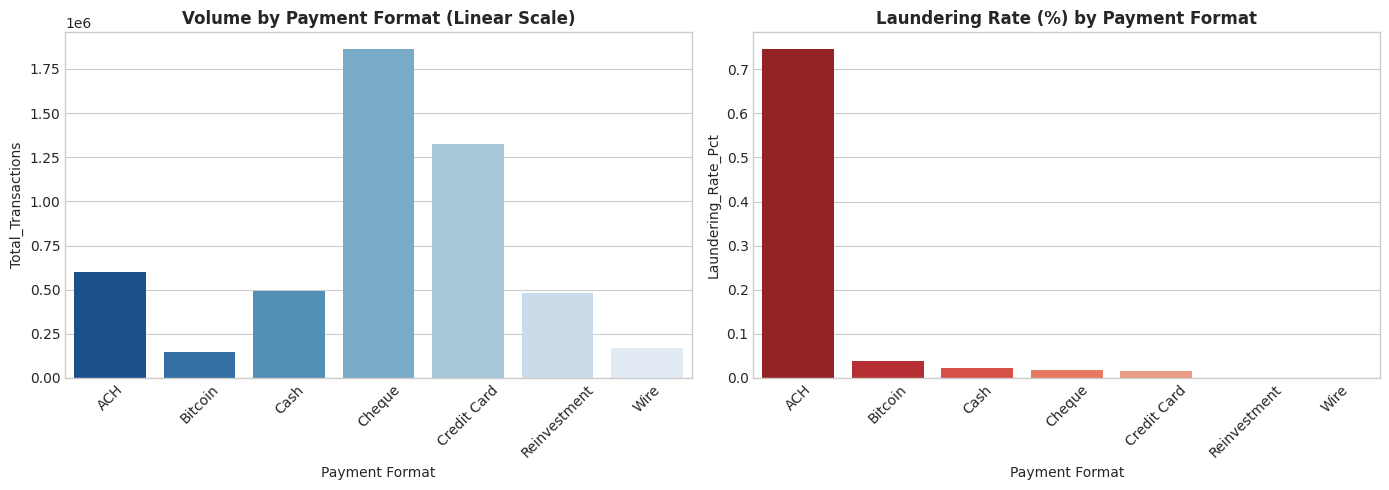

In [ ]:
# Read-only format risk summary
format_stats = hi_small_trans_full.groupby('Payment Format').agg(
    Total_Transactions=('Is Laundering', 'count'),
    Laundering_Count=('Is Laundering', 'sum'),
    Laundering_Rate_Pct=('Is Laundering', lambda x: (x.sum() / len(x)) * 100)
).sort_values(by='Laundering_Rate_Pct', ascending=False)

display(format_stats.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Total Volume by Payment Format (Escala linear, sem transformações)
sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Blues_r')
ax[0].set_title('Volume by Payment Format (Linear Scale)', fontsize=12, fontweight='bold')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Laundering Rate by Payment Format
sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Reds_r')
ax[1].set_title('Laundering Rate (%) by Payment Format', fontsize=12, fontweight='bold')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

#### Payment Channel Analysis Insights

The analysis reveals that while checks and credit cards dominate the total volume of network operations, the ACH method accounts for a highly disproportionate share of the highest money laundering rate (approximately 0.75%), recording the highest absolute number of suspicious cases. In contrast, channels such as reinvestments and wire transfers show no recorded incidents, maintaining a zero-risk rate within this sample.

### 6. Inter-Bank vs. Intra-Bank Laundering Distribution Analysis

Inspecting inter and intra-bank relationships.

In [ ]:
# Calcular o total geral de casos de laundering
total_laundering_cases = interbank_table['Laundering'].sum()

# Calcular a percentagem de participação de cada grupo no total de laundering
interbank_table['Laundering(%)'] = (
    interbank_table['Laundering'] / total_laundering_cases
) * 100

# Filtrar para manter apenas as colunas pretendidas
interbank_table = interbank_table[['Total', 'Laundering', 'Laundering(%)']]

display(interbank_table.round(4))

,Total,Laundering,Laundering(%)
Intra-Bank (Same Bank),691332,103,1.9896
Inter-Bank (Different Banks),4387013,5074,98.0104


The analysis reveals that money laundering occurs almost exclusively between different banks, accounting for 98.01% of detected cases (5,074 occurrences). In contrast, transactions within the same bank represent a negligible share of just 1.99% (103 cases), demonstrating that malicious actors deliberately exploit interbank fragmentation to obscure the trail of funds.